Assignment: Food Delivery Data Visualization Portfolio (Day 14)

Using the provided Food Delivery Business Performance Dataset (can be found in the "Study Material" tab of the LMS), create a visualization portfolio using Matplotlib and Seaborn to explore and communicate meaningful patterns in the data. Create appropriate visualizations such as line plots, bar charts, scatter plots, histograms, box plots, violin plots, count plots, and a correlation heatmap, selecting the chart type based on what you want to investigate. Include proper titles, axis labels, legends, and suitable formatting for each visualization, and use the charts to investigate trends such as changes in orders and revenue over time, differences between cities or cuisines, relationships between marketing spend and revenue, delivery time and customer ratings, and the effect of weather or order channels on performance. For each visualization, provide a brief interpretation of the insight revealed by the chart and conclude with a summary of the most important findings from your analysis. The assignment should be submitted as a Jupyter/Google Colab notebook uploaded on a public GitHub Repository containing the complete visualization portfolio and interpretations.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
data = pd.read_csv("Day14_Food_Delivery_Visualization_Dataset.csv")
data

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,FD0356,2025-05-17,May,Saturday,Hyderabad,South Indian,Website,Hot,173,345.70,54617.02,23218.25,3545.94,34.0,4.38,32.7
356,FD0357,2025-09-19,September,Friday,Jaipur,Chinese,App,Clear,84,368.12,43172.89,36244.79,7910.39,27.6,4.39,42.6
357,FD0358,2025-04-18,April,Friday,Bengaluru,Biryani,Partner Platform,Rainy,148,431.35,67272.24,18853.98,6147.45,41.1,4.09,30.2
358,FD0359,2025-11-21,November,Friday,Mumbai,Healthy,App,Clear,179,483.13,88272.94,38950.88,13430.03,30.5,4.64,49.0


## 1. Data Understanding


In [29]:
data.shape

(360, 16)

In [30]:
data.dtypes

Order_Batch_ID              object
Date                        object
Month                       object
Day                         object
City                        object
Cuisine                     object
Order_Channel               object
Weather                     object
Orders                       int64
Average_Order_Value        float64
Revenue                    float64
Marketing_Spend            float64
Discounts                  float64
Avg_Delivery_Minutes       float64
Customer_Rating            float64
Repeat_Customer_Percent    float64
dtype: object

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_Batch_ID           360 non-null    object 
 1   Date                     360 non-null    object 
 2   Month                    360 non-null    object 
 3   Day                      360 non-null    object 
 4   City                     360 non-null    object 
 5   Cuisine                  360 non-null    object 
 6   Order_Channel            360 non-null    object 
 7   Weather                  360 non-null    object 
 8   Orders                   360 non-null    int64  
 9   Average_Order_Value      360 non-null    float64
 10  Revenue                  360 non-null    float64
 11  Marketing_Spend          360 non-null    float64
 12  Discounts                360 non-null    float64
 13  Avg_Delivery_Minutes     360 non-null    float64
 14  Customer_Rating          3

In [32]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Orders,360.0,147.647222,33.387161,58.00,123.7500,147.00,169.0000,235.00
Average_Order_Value,360.0,409.151083,70.249186,243.76,353.8400,412.41,464.9450,575.94
Revenue,360.0,60591.114778,17387.926132,20618.53,48400.8325,58779.19,71740.1425,121381.98
Marketing_Spend,360.0,27161.430028,6970.558278,11336.64,21822.5000,25874.14,32387.1375,45000.00
Discounts,360.0,5753.397000,2647.410844,1219.31,3566.6150,5226.87,7610.3675,15000.00
Avg_Delivery_Minutes,360.0,32.577500,5.281562,20.60,28.6750,32.00,35.9500,50.10
Customer_Rating,360.0,4.452861,0.209699,3.81,4.3100,4.47,4.6100,4.94
Repeat_Customer_Percent,360.0,41.600000,5.336472,24.80,37.9000,41.90,45.2250,54.00


## 2. Data Quality Check


In [34]:
print("any missing values in data:", data.isnull().sum().sum())
print("duplicate rows found:", data.duplicated().sum())


any missing values in data: 0
duplicate rows found: 0


In [35]:
print("how many cities we have:", data["City"].nunique())
print("how many cuisine types:", data["Cuisine"].nunique())
print("order channels are:", list(data["Order_Channel"].unique()))
print("weather types are:", list(data["Weather"].unique()))

how many cities we have: 8
how many cuisine types: 6
order channels are: ['App', 'Partner Platform', 'Website']
weather types are: ['Hot', 'Rainy', 'Clear', 'Cloudy']


## 3. Line Plot - Orders and Revenue Over Time



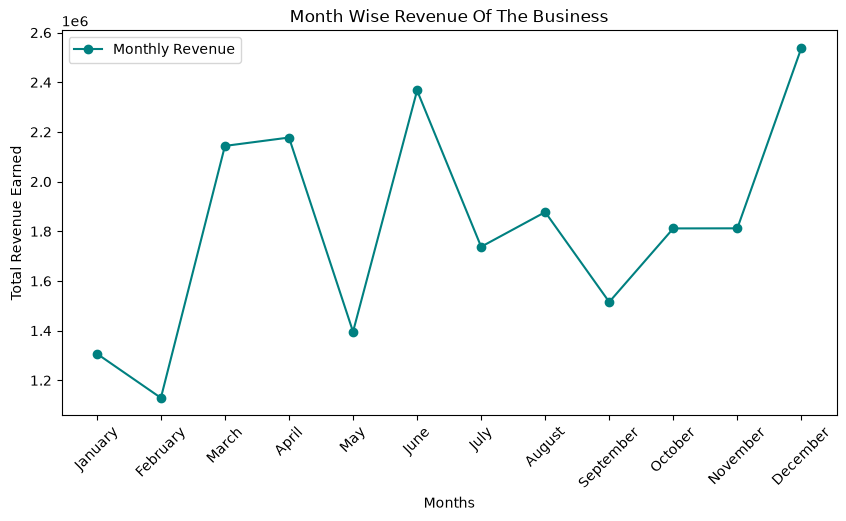

so best earning month is: December with revenue around 2538435
weakest month is: February with only 1129273


In [36]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

monthly_revenue = data.groupby("Month")["Revenue"].sum().reindex(month_order)

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o", color="teal", label="Monthly Revenue")
plt.title("Month Wise Revenue Of The Business")
plt.xlabel("Months")
plt.ylabel("Total Revenue Earned")
plt.xticks(rotation=45)
plt.legend()
plt.show()

print("so best earning month is:", monthly_revenue.idxmax(), "with revenue around", round(monthly_revenue.max()))
print("weakest month is:", monthly_revenue.idxmin(), "with only", round(monthly_revenue.min()))

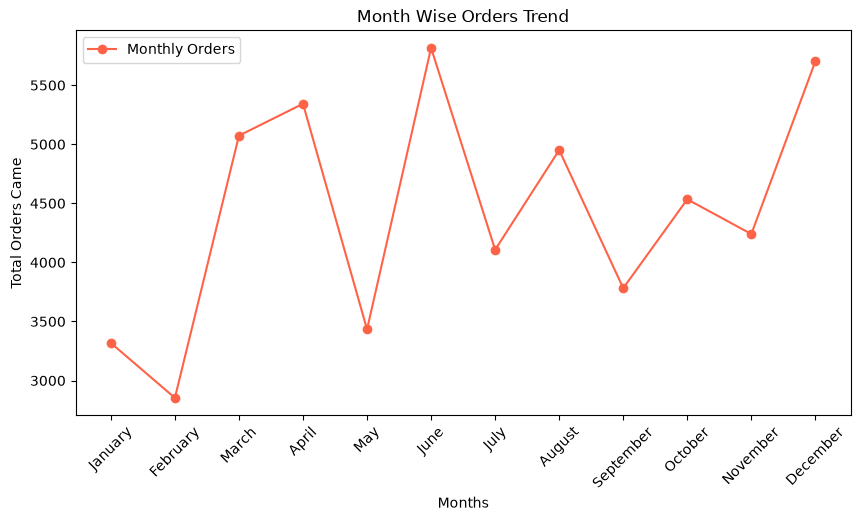

most orders came in: June -> 5816 orders
least orders in: February -> 2853 orders


In [37]:
monthly_orders = data.groupby("Month")["Orders"].sum().reindex(month_order)

plt.figure(figsize=(10, 5))
plt.plot(monthly_orders.index, monthly_orders.values, marker="o", color="tomato", label="Monthly Orders")
plt.title("Month Wise Orders Trend")
plt.xlabel("Months")
plt.ylabel("Total Orders Came")
plt.xticks(rotation=45)
plt.legend()
plt.show()

print("most orders came in:", monthly_orders.idxmax(), "->", monthly_orders.max(), "orders")
print("least orders in:", monthly_orders.idxmin(), "->", monthly_orders.min(), "orders")

## 4. Bar Chart - City and Cuisine Comparison



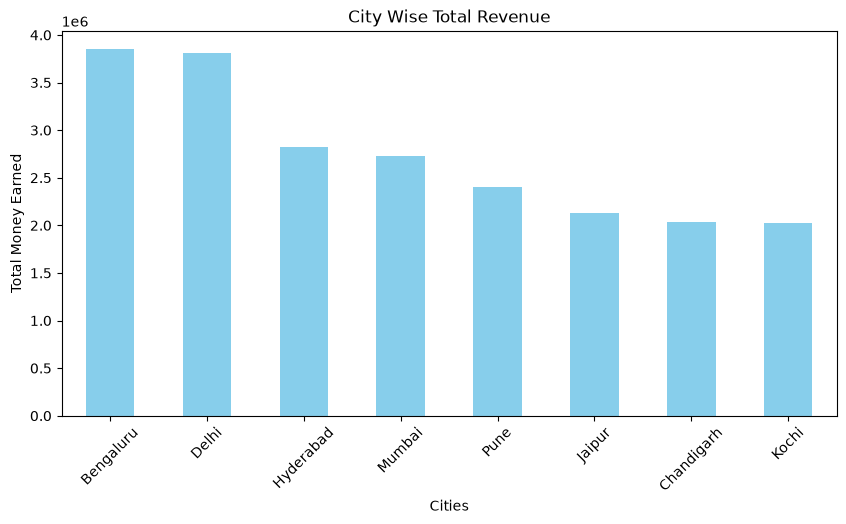

top earning city is: Bengaluru
city giving lowest revenue: Kochi


In [38]:
city_revenue = data.groupby("City")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
city_revenue.plot(kind="bar", color="skyblue")
plt.title("City Wise Total Revenue")
plt.xlabel("Cities")
plt.ylabel("Total Money Earned")
plt.xticks(rotation=45)
plt.show()

print("top earning city is:", city_revenue.idxmax())
print("city giving lowest revenue:", city_revenue.idxmin())

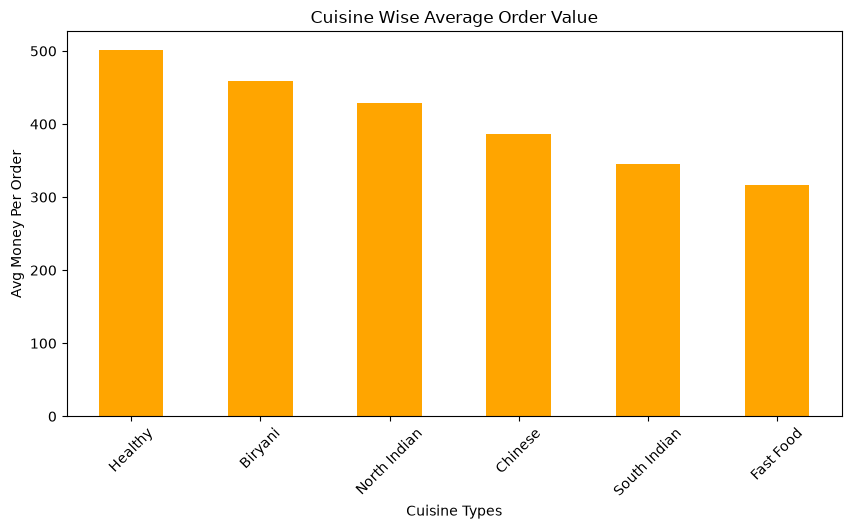

Cuisine
Healthy         501.8
Biryani         458.9
North Indian    428.9
Chinese         386.1
South Indian    344.9
Fast Food       316.7
Name: Average_Order_Value, dtype: float64


In [39]:
cuisine_aov = data.groupby("Cuisine")["Average_Order_Value"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
cuisine_aov.plot(kind="bar", color="orange")
plt.title("Cuisine Wise Average Order Value")
plt.xlabel("Cuisine Types")
plt.ylabel("Avg Money Per Order")
plt.xticks(rotation=45)
plt.show()

print(cuisine_aov.round(1))

## 5. Histogram - Distribution of Values



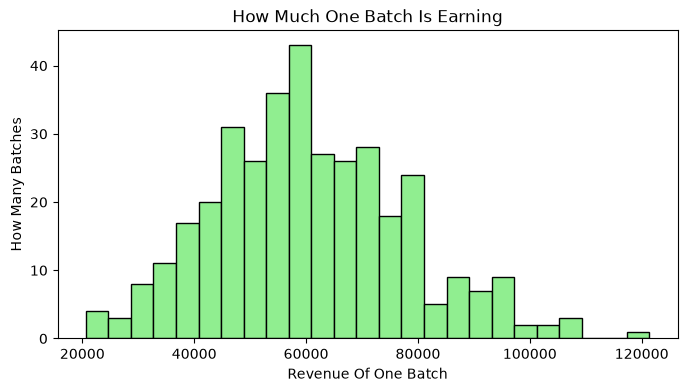

smallest batch earning: 20619
biggest batch earning: 121382


In [40]:
plt.figure(figsize=(8, 4))
plt.hist(data["Revenue"], bins=25, color="lightgreen", edgecolor="black")
plt.title("How Much One Batch Is Earning")
plt.xlabel("Revenue Of One Batch")
plt.ylabel("How Many Batches")
plt.show()

print("smallest batch earning:", round(data["Revenue"].min()))
print("biggest batch earning:", round(data["Revenue"].max()))

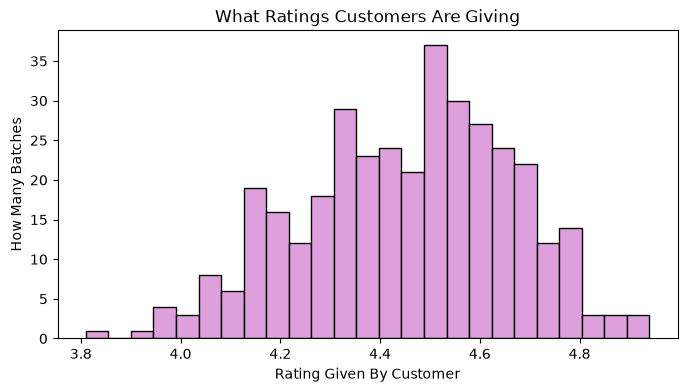

average rating overall: 4.45


In [41]:
plt.figure(figsize=(8, 4))
plt.hist(data["Customer_Rating"], bins=25, color="plum", edgecolor="black")
plt.title("What Ratings Customers Are Giving")
plt.xlabel("Rating Given By Customer")
plt.ylabel("How Many Batches")
plt.show()

print("average rating overall:", round(data["Customer_Rating"].mean(), 2))

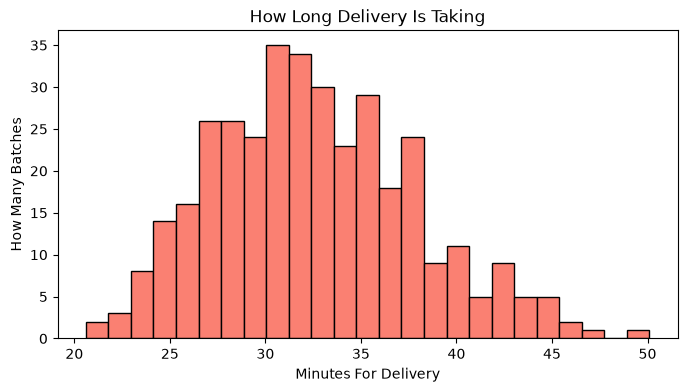

fastest delivery done in: 20.6 minutes only
slowest delivery went till: 50.1 minutes


In [42]:
plt.figure(figsize=(8, 4))
plt.hist(data["Avg_Delivery_Minutes"], bins=25, color="salmon", edgecolor="black")
plt.title("How Long Delivery Is Taking")
plt.xlabel("Minutes For Delivery")
plt.ylabel("How Many Batches")
plt.show()

print("fastest delivery done in:", data["Avg_Delivery_Minutes"].min(), "minutes only")
print("slowest delivery went till:", data["Avg_Delivery_Minutes"].max(), "minutes")

## 6. Scatter Plot - Relationship Between Two Numbers


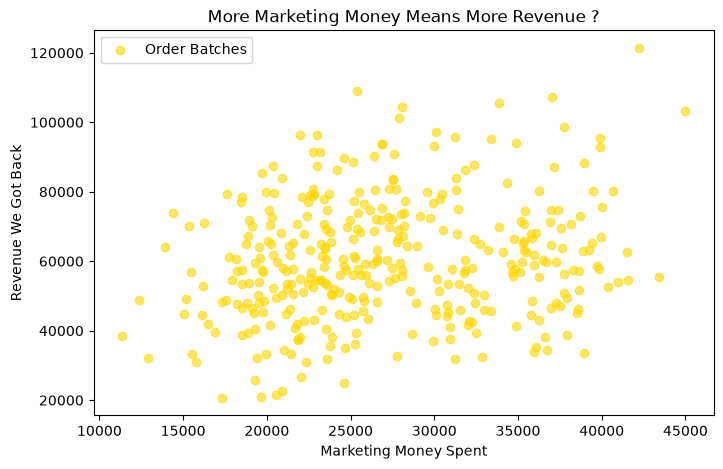

correlation between marketing spend and revenue: 0.2


In [43]:
plt.figure(figsize=(8, 5))
plt.scatter(data["Marketing_Spend"], data["Revenue"], color="gold", alpha=0.6)
plt.title("More Marketing Money Means More Revenue ?")
plt.xlabel("Marketing Money Spent")
plt.ylabel("Revenue We Got Back")
plt.legend(["Order Batches"])
plt.show()

print("correlation between marketing spend and revenue:", round(data["Marketing_Spend"].corr(data["Revenue"]), 2))

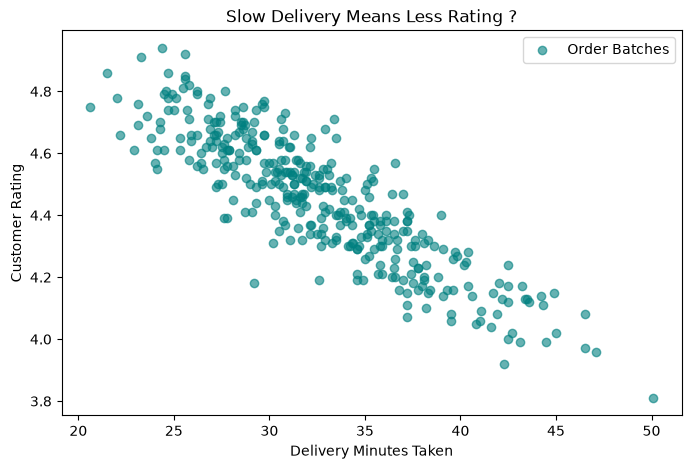

correlation between delivery time and rating: -0.88


In [44]:
plt.figure(figsize=(8, 5))
plt.scatter(data["Avg_Delivery_Minutes"], data["Customer_Rating"], color="teal", alpha=0.6)
plt.title("Slow Delivery Means Less Rating ?")
plt.xlabel("Delivery Minutes Taken")
plt.ylabel("Customer Rating")
plt.legend(["Order Batches"])
plt.show()

print("correlation between delivery time and rating:", round(data["Avg_Delivery_Minutes"].corr(data["Customer_Rating"]), 2))

## 7. Box Plot - Effect of Weather on Delivery Time



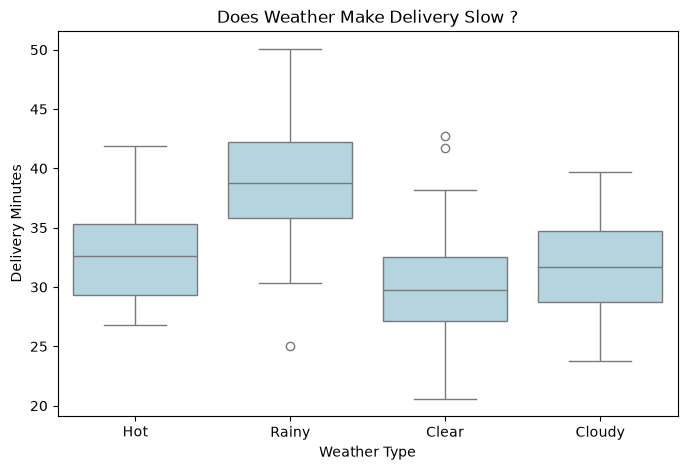

         Avg_Delivery_Min  Avg_Rating  Total_Orders
Weather                                            
Clear                30.0         4.5         21564
Cloudy               31.7         4.5         13628
Hot                  32.5         4.5          6853
Rainy                38.7         4.2         11108


In [45]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Weather", y="Avg_Delivery_Minutes", data=data, color="lightblue")
plt.title("Does Weather Make Delivery Slow ?")
plt.xlabel("Weather Type")
plt.ylabel("Delivery Minutes")
plt.show()

weather_check = data.groupby("Weather").agg(
    Avg_Delivery_Min=("Avg_Delivery_Minutes", "mean"),
    Avg_Rating=("Customer_Rating", "mean"),
    Total_Orders=("Orders", "sum"))
print(weather_check.round(1))

## 8. Violin Plot - Customer Rating By Cuisine



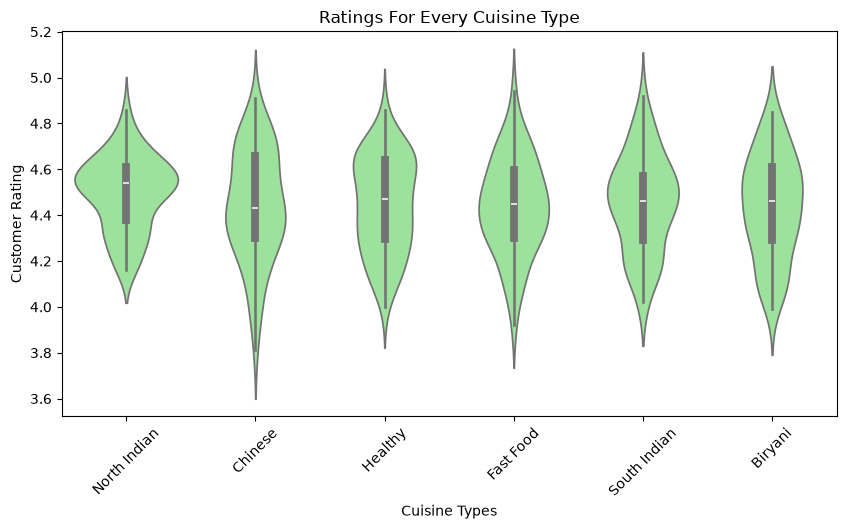

Cuisine
North Indian    4.50
Healthy         4.45
South Indian    4.45
Biryani         4.44
Chinese         4.44
Fast Food       4.44
Name: Customer_Rating, dtype: float64


In [46]:
plt.figure(figsize=(10, 5))
sns.violinplot(x="Cuisine", y="Customer_Rating", data=data, color="lightgreen")
plt.title("Ratings For Every Cuisine Type")
plt.xlabel("Cuisine Types")
plt.ylabel("Customer Rating")
plt.xticks(rotation=45)
plt.show()

print(data.groupby("Cuisine")["Customer_Rating"].mean().round(2).sort_values(ascending=False))

## 9. Count Plot - Order Channels and Weather



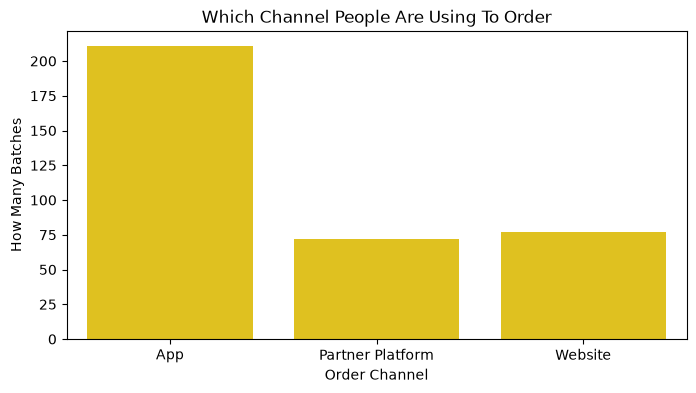

Order_Channel
App                 211
Website              77
Partner Platform     72
Name: count, dtype: int64


In [47]:
plt.figure(figsize=(8, 4))
sns.countplot(x="Order_Channel", data=data, color="gold")
plt.title("Which Channel People Are Using To Order")
plt.xlabel("Order Channel")
plt.ylabel("How Many Batches")
plt.show()

print(data["Order_Channel"].value_counts())

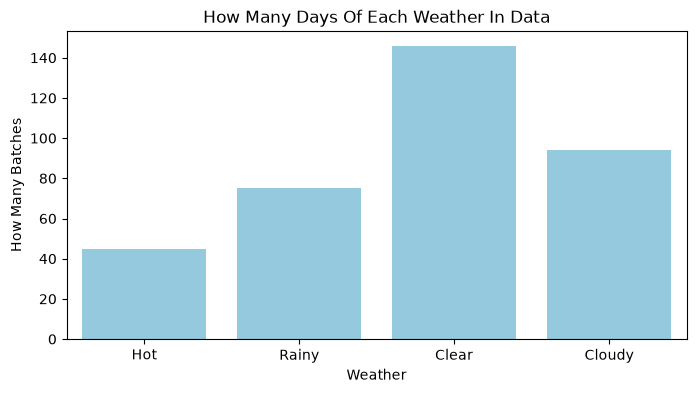

Weather
Clear     146
Cloudy     94
Rainy      75
Hot        45
Name: count, dtype: int64


In [48]:
plt.figure(figsize=(8, 4))
sns.countplot(x="Weather", data=data, color="skyblue")
plt.title("How Many Days Of Each Weather In Data")
plt.xlabel("Weather")
plt.ylabel("How Many Batches")
plt.show()

print(data["Weather"].value_counts())

## 10. Correlation Heatmap


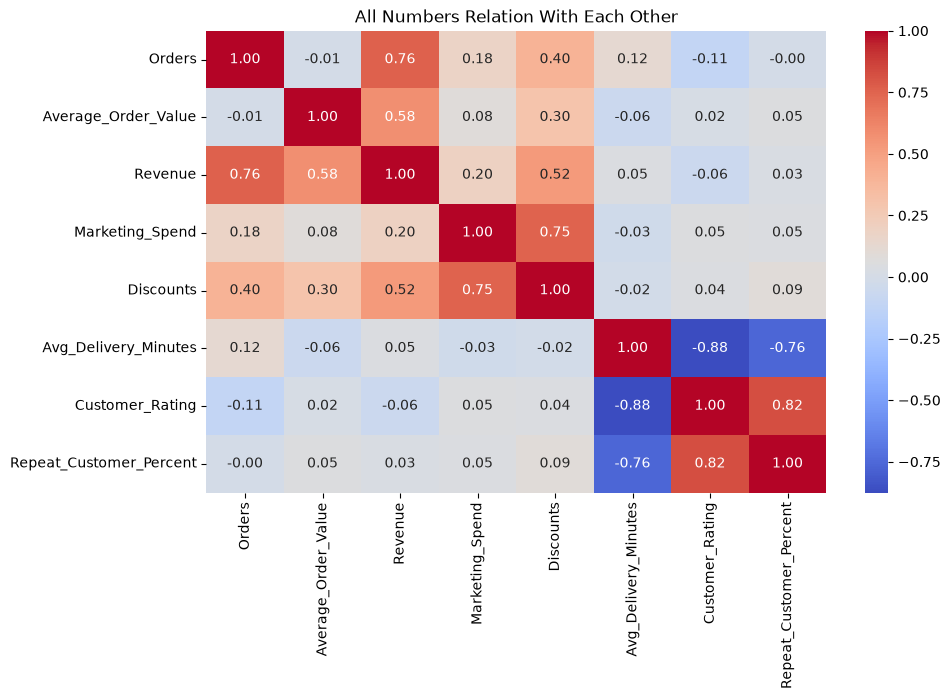

orders and revenue move together: 0.76
discount effect on orders: 0.4
repeat customers vs happy rating: 0.82


In [49]:
num_cols = ["Orders", "Average_Order_Value", "Revenue", "Marketing_Spend",
            "Discounts", "Avg_Delivery_Minutes", "Customer_Rating",
            "Repeat_Customer_Percent"]

plt.figure(figsize=(10, 6))
sns.heatmap(data[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("All Numbers Relation With Each Other")
plt.show()

print("orders and revenue move together:", round(data["Orders"].corr(data["Revenue"]), 2))
print("discount effect on orders:", round(data["Discounts"].corr(data["Orders"]), 2))
print("repeat customers vs happy rating:", round(data["Repeat_Customer_Percent"].corr(data["Customer_Rating"]), 2))

**Insight:**
- Orders strongly drive Revenue (+0.76), which is obvious for delivery business.
- Discounts vs Orders moderate positive relation (+0.40), discounts do bring extra orders.
- Repeat_Customer_Percent goes together with high ratings (+0.82), happy customers come back again.
- Marketing spend stays weak against everything, marketing alone cannot fix sales.
- Delivery time has strongest negative relation (-0.88) with ratings, same finding as scatter plot.

## 11. Final Summary - Most Important Findings

1. **Time trend:** December is best month for revenue and June for orders, February is weakest month. Year end season should get maximum focus.
2. **Cities:** Bengaluru and Delhi earn highest revenue, Kochi earns least. Resources should match city demand.
3. **Cuisines:** Healthy food brings highest average order value (around Rs 500) and Fast Food lowest. Premium cuisines deserve more promotion.
4. **Biggest insight:** Delivery time has strong negative relation (-0.88) with customer rating. Fast delivery keeps customers happy and slow delivery destroys ratings.
5. **Weather effect:** Rainy weather increases delivery time (about 39 min) and drops ratings to 4.23, while clear weather is fastest with best ratings (4.53).
6. **Channel effect:** App dominates all other channels and also gives highest order value, Partner Platform performs worst.
7. **Money matters:** Discounts increase orders moderately, but marketing spend alone has weak link with revenue.

**Business advice:** Focus on fast delivery (add more riders during rain and December rush), promote App channel, push premium cuisines like Healthy and Biryani, run discount campaigns in weak months like February, and invest marketing money in top cities instead of spreading everywhere.